# CAHSI Data Analytics Challenge

Regression, scored by **R2**. Submission: `answer.txt` — one non-negative float per row, no header.

Run top-to-bottom. Logic lives in `src/pipeline.py`. When real data drops: put CSVs in `data/`, fix CONFIG, rerun.

## 0. Config — only place paths/columns are hardcoded

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

TRAIN_PATH = REPO_ROOT / "data" / "train.csv"
TEST_PATH = REPO_ROOT / "data" / "test.csv"
TARGET_COL = "target"      # <-- change when real data drops
ID_COL = None              # <-- set if real data has an id column to drop
SUBMISSION_PATH = REPO_ROOT / "answer.txt"
FINAL_MODEL = "random_forest"  # baseline / linear / random_forest / xgboost / lightgbm

## 1. Load + inspect

In [2]:
import pipeline as pl

train_raw, test_raw = pl.load_data(TRAIN_PATH, TEST_PATH)
print(f"train {train_raw.shape} | test {test_raw.shape}")
print(train_raw.isna().sum())
train_raw.head()

train (500, 10) | test (200, 9)
age           23
income        28
score_a       23
score_b       30
num_visits    26
region        20
device        30
plan          24
city          33
target         0
dtype: int64


,age,income,score_a,score_b,num_visits,region,device,plan,city,target
0,23.0,53303.27,56.9,NaN,4.0,east,desktop,enterprise,city_24,127.05
1,65.0,23360.89,59.0,54.9,3.0,west,mobile,NaN,city_12,132.77
2,58.0,28593.19,84.9,38.1,4.0,west,mobile,enterprise,city_15,135.95
3,45.0,93326.45,0.5,50.4,5.0,south,mobile,basic,city_05,136.66
4,44.0,NaN,85.3,NaN,6.0,east,desktop,free,city_29,135.00


count    500.000000
mean     136.611140
std       10.627714
min      105.730000
25%      129.660000
50%      136.695000
75%      143.607500
max      169.650000
Name: target, dtype: float64

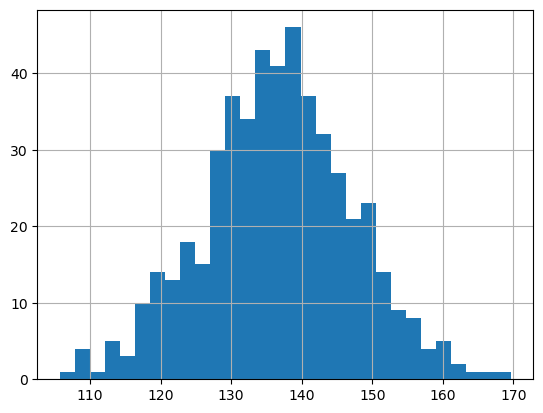

In [3]:
train_raw[TARGET_COL].hist(bins=30)
train_raw[TARGET_COL].describe()

## 2. Clean + encode

In [4]:
train_clean, test_clean = pl.clean_data(train_raw, test_raw, TARGET_COL)
X_train, y_train, X_test = pl.encode_features(train_clean, test_clean, TARGET_COL, ID_COL)
print(f"X_train {X_train.shape} | X_test {X_test.shape}")

X_train (500, 17) | X_test (200, 17)


## 3. Cross-validation — R2, higher is better

In [5]:
cv_results = pl.evaluate_models(X_train, y_train)
cv_results

  baseline: r2=-0.0036 ± 0.0020
  linear: r2=0.7649 ± 0.0357


  random_forest: r2=0.7013 ± 0.0211


  xgboost: r2=0.6657 ± 0.0391


  lightgbm: r2=0.6941 ± 0.0192


,r2_mean,r2_std
model,,
linear,0.764949,0.035728
random_forest,0.701322,0.021121
lightgbm,0.694124,0.019164
xgboost,0.665688,0.039106
baseline,-0.003618,0.002046


## 4. Final model → answer.txt

In [6]:
preds = pl.train_and_predict(FINAL_MODEL, X_train, y_train, X_test)
final = pl.export_submission(preds, SUBMISSION_PATH)
assert len(final) == len(test_raw)

Wrote /Users/cmeraz/Desktop/DataDorks/answer.txt: 200 rows, min=114.0210, max=157.7929
